# NML502 Project

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

file_path = r"C:\Users\alber\OneDrive\Desktop\Rice\Semesters\Spring 2026\ELEC502 - Neural Machine Learning 1\Project\LGN11_20260328_day_pointer_v1_trial_response_arrays (3).h5"

with h5py.File(file_path, "r") as f:
    channel = np.asarray(f["/channel"]).astype(int).reshape(-1)
    current_uA = np.asarray(f["/current_uA"]).astype(float).reshape(-1)
    v1_response_grid = np.asarray(f["/v1_response_grid"], dtype=float)
    v1_mask = np.asarray(f["/v1_mask"]).astype(bool) if "/v1_mask" in f else None
    final_mask = np.asarray(f["/final_mask"]).astype(bool) if "/final_mask" in f else None

if v1_response_grid.shape[0] != channel.size and v1_response_grid.shape[-1] == channel.size:
    v1_response_grid = np.transpose(v1_response_grid, (2, 1, 0))

grid_shape = v1_response_grid.shape[1:]
if v1_mask is not None and v1_mask.shape != grid_shape and v1_mask.T.shape == grid_shape:
    v1_mask = v1_mask.T
if final_mask is not None and final_mask.shape != grid_shape and final_mask.T.shape == grid_shape:
    final_mask = final_mask.T

print("v1_response_grid shape:", v1_response_grid.shape)


v1_response_grid shape: (1980, 27, 35)


C:\Users\alber\AppData\Local\Temp\ipykernel_36300\3718955223.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("plasma").copy()   # change this


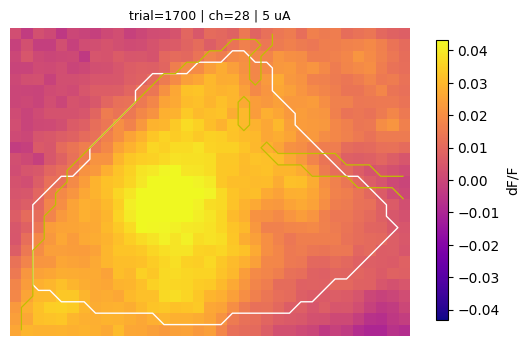

In [4]:
trial_indices = [1700]

finite_vals = []
for i in trial_indices:
    vals = v1_response_grid[i][np.isfinite(v1_response_grid[i])]
    if vals.size:
        finite_vals.append(vals)

merged = np.concatenate(finite_vals)
lo, hi = np.quantile(merged, [0.02, 0.98])
vmax = max(abs(lo), abs(hi))
clim = (-vmax, vmax)

fig, axes = plt.subplots(
    1,
    len(trial_indices),
    figsize=(4.5 * len(trial_indices) + 1.2, 4),
    squeeze=False
)
axes = axes.ravel()

cmap = plt.cm.get_cmap("plasma").copy()   # change this
cmap.set_bad(color=(1, 1, 1, 0))

last_im = None
for ax, i in zip(axes, trial_indices):
    img = np.ma.masked_invalid(v1_response_grid[i])
    last_im = ax.imshow(img, cmap=cmap, vmin=clim[0], vmax=clim[1], interpolation="nearest")

    if v1_mask is not None:
        ax.contour(v1_mask.astype(float), levels=[0.5], colors="w", linewidths=1.0)
    if final_mask is not None:
        ax.contour(final_mask.astype(float), levels=[0.5], colors="y", linewidths=0.9)

    ax.set_title(f"trial={i} | ch={channel[i]} | {current_uA[i]:g} uA", fontsize=9)
    ax.axis("off")

fig.subplots_adjust(right=0.88, wspace=0.15)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])  # [left, bottom, width, height]
fig.colorbar(last_im, cax=cbar_ax, label="dF/F")

plt.show()


In [38]:
import numpy as np
import matplotlib.pyplot as plt

def bin_2d_nanmean(img, factor):
    h, w = img.shape
    h2 = h // factor
    w2 = w // factor
    cropped = img[:h2 * factor, :w2 * factor]
    reshaped = cropped.reshape(h2, factor, w2, factor)
    return np.nanmean(reshaped, axis=(1, 3))

def compare_binning(trial_idx, cmap="bwr"):
    img1 = np.array(v1_response_grid[trial_idx], dtype=float)
    img2 = bin_2d_nanmean(img1, 2)
    img4 = bin_2d_nanmean(img1, 4)

    finite_vals = []
    for img in [img1, img2, img4]:
        vals = img[np.isfinite(img)]
        if vals.size:
            finite_vals.append(vals)

    merged = np.concatenate(finite_vals)
    lo, hi = np.quantile(merged, [0.02, 0.98])
    vmax = max(abs(lo), abs(hi))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    cmap_obj = plt.cm.get_cmap(cmap).copy()
    cmap_obj.set_bad(color=(1, 1, 1, 0))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    last_im = None

    for ax, img, title in zip(
        axes,
        [img1, img2, img4],
        [f"1x\n{img1.shape}", f"2x binned\n{img2.shape}", f"4x binned\n{img4.shape}"],
    ):
        last_im = ax.imshow(
            np.ma.masked_invalid(img),
            cmap=cmap_obj,
            vmin=-vmax,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"trial={trial_idx} | ch={channel[trial_idx]} | {current_uA[trial_idx]:g} uA")
    fig.subplots_adjust(right=0.88, wspace=0.12)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
    fig.colorbar(last_im, cax=cbar_ax, label="dF/F")
    plt.show()


C:\Users\alber\AppData\Local\Temp\ipykernel_21452\1573012109.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()


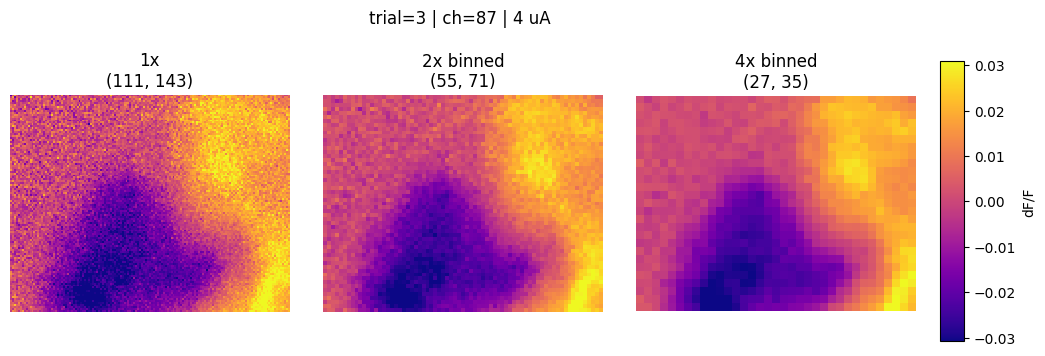

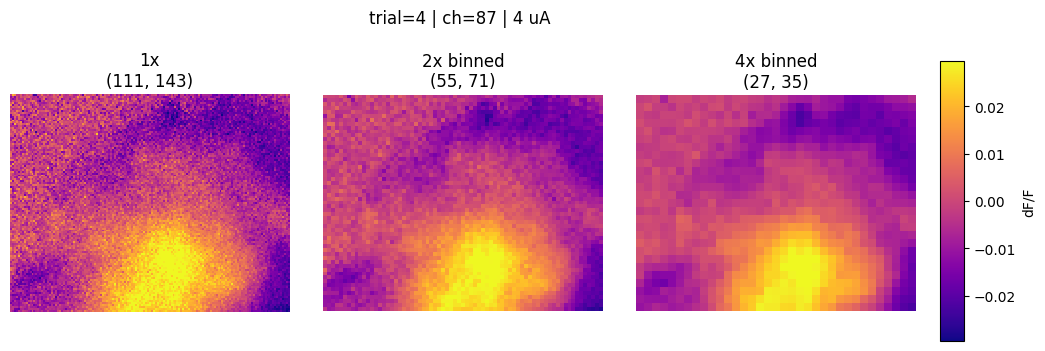

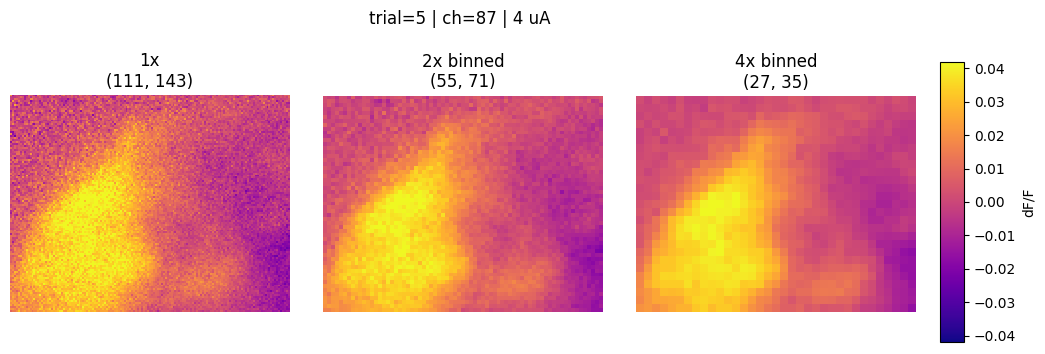

In [44]:
compare_binning(3, cmap="plasma")
compare_binning(4, cmap="plasma")
compare_binning(5, cmap="plasma")


In [ ]:
np.isfinite(v1_grid[0]).any()

False

In [24]:
print("v1_grid shape:", v1_grid.shape)

def plot_v1_grid_trials(trial_indices, cmap="bwr"):
    trial_indices = [int(i) for i in trial_indices]

    finite_vals = []
    for idx in trial_indices:
        vals = v1_grid[idx][np.isfinite(v1_grid[idx])]
        if vals.size:
            finite_vals.append(vals)

    if not finite_vals:
        print("No finite values found in the selected trials.")
        return

    merged = np.concatenate(finite_vals)
    lo, hi = np.quantile(merged, [0.02, 0.98])
    vmax = max(abs(lo), abs(hi))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    ncols = min(3, len(trial_indices))
    nrows = int(np.ceil(len(trial_indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows), squeeze=False)
    axes = axes.ravel()

    cm = plt.cm.get_cmap(cmap).copy()
    cm.set_bad(color=(1, 1, 1, 0))  # transparent where NaN

    last_im = None
    for ax, idx in zip(axes, trial_indices):
        img = np.ma.masked_invalid(v1_grid[idx])
        last_im = ax.imshow(img, cmap=cm, vmin=-vmax, vmax=vmax, interpolation="nearest")

        channel = int(np.asarray(channels[idx]).reshape(-1)[0])
        current = float(np.asarray(currents[idx]).reshape(-1)[0])
        n_finite = np.isfinite(v1_grid[idx]).sum()

        ax.set_title(f"trial {idx} | ch {channel} | {current:g} uA\nn={n_finite} finite px")
        ax.set_facecolor("white")
        ax.axis("off")

    for ax in axes[len(trial_indices):]:
        ax.axis("off")

    fig.colorbar(last_im, ax=axes.tolist(), shrink=0.85, label="dF/F")
    plt.tight_layout()
    plt.show()


plot_v1_grid_trials([0, 1, 2])


v1_grid shape: (143, 111, 1980)
No finite values found in the selected trials.
